<h1>DSCI 552 Homework 1</h1>

Name: Madhulika Vikraman

GitHub Username: madhulikavikraman

USC ID: 2083047114


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.io import arff
from sklearn.neighbors import KNeighborsClassifier


1) (a) Download the Vertebral Column Data Set, and replace Abnormal with 1 and Normal with 0.

In [30]:
file = arff.loadarff('../data/column_2C_weka.arff')
df = pd.DataFrame(file[0])
df["class"] = df["class"].str.decode('utf-8')
df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Abnormal


In [31]:
df["class"] = df["class"].replace("Abnormal", 1)
df["class"] = df["class"].replace("Normal", 0)
df

C:\Users\madhu\AppData\Local\Temp\ipykernel_47684\108682991.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace("Normal", 0)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,1
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,1
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,1
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,1
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,1
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,0
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,0
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,0
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,0


1) (b) i. Make scatterplots of the independent variables in the dataset. Use color to
show Classes 0 and 1.

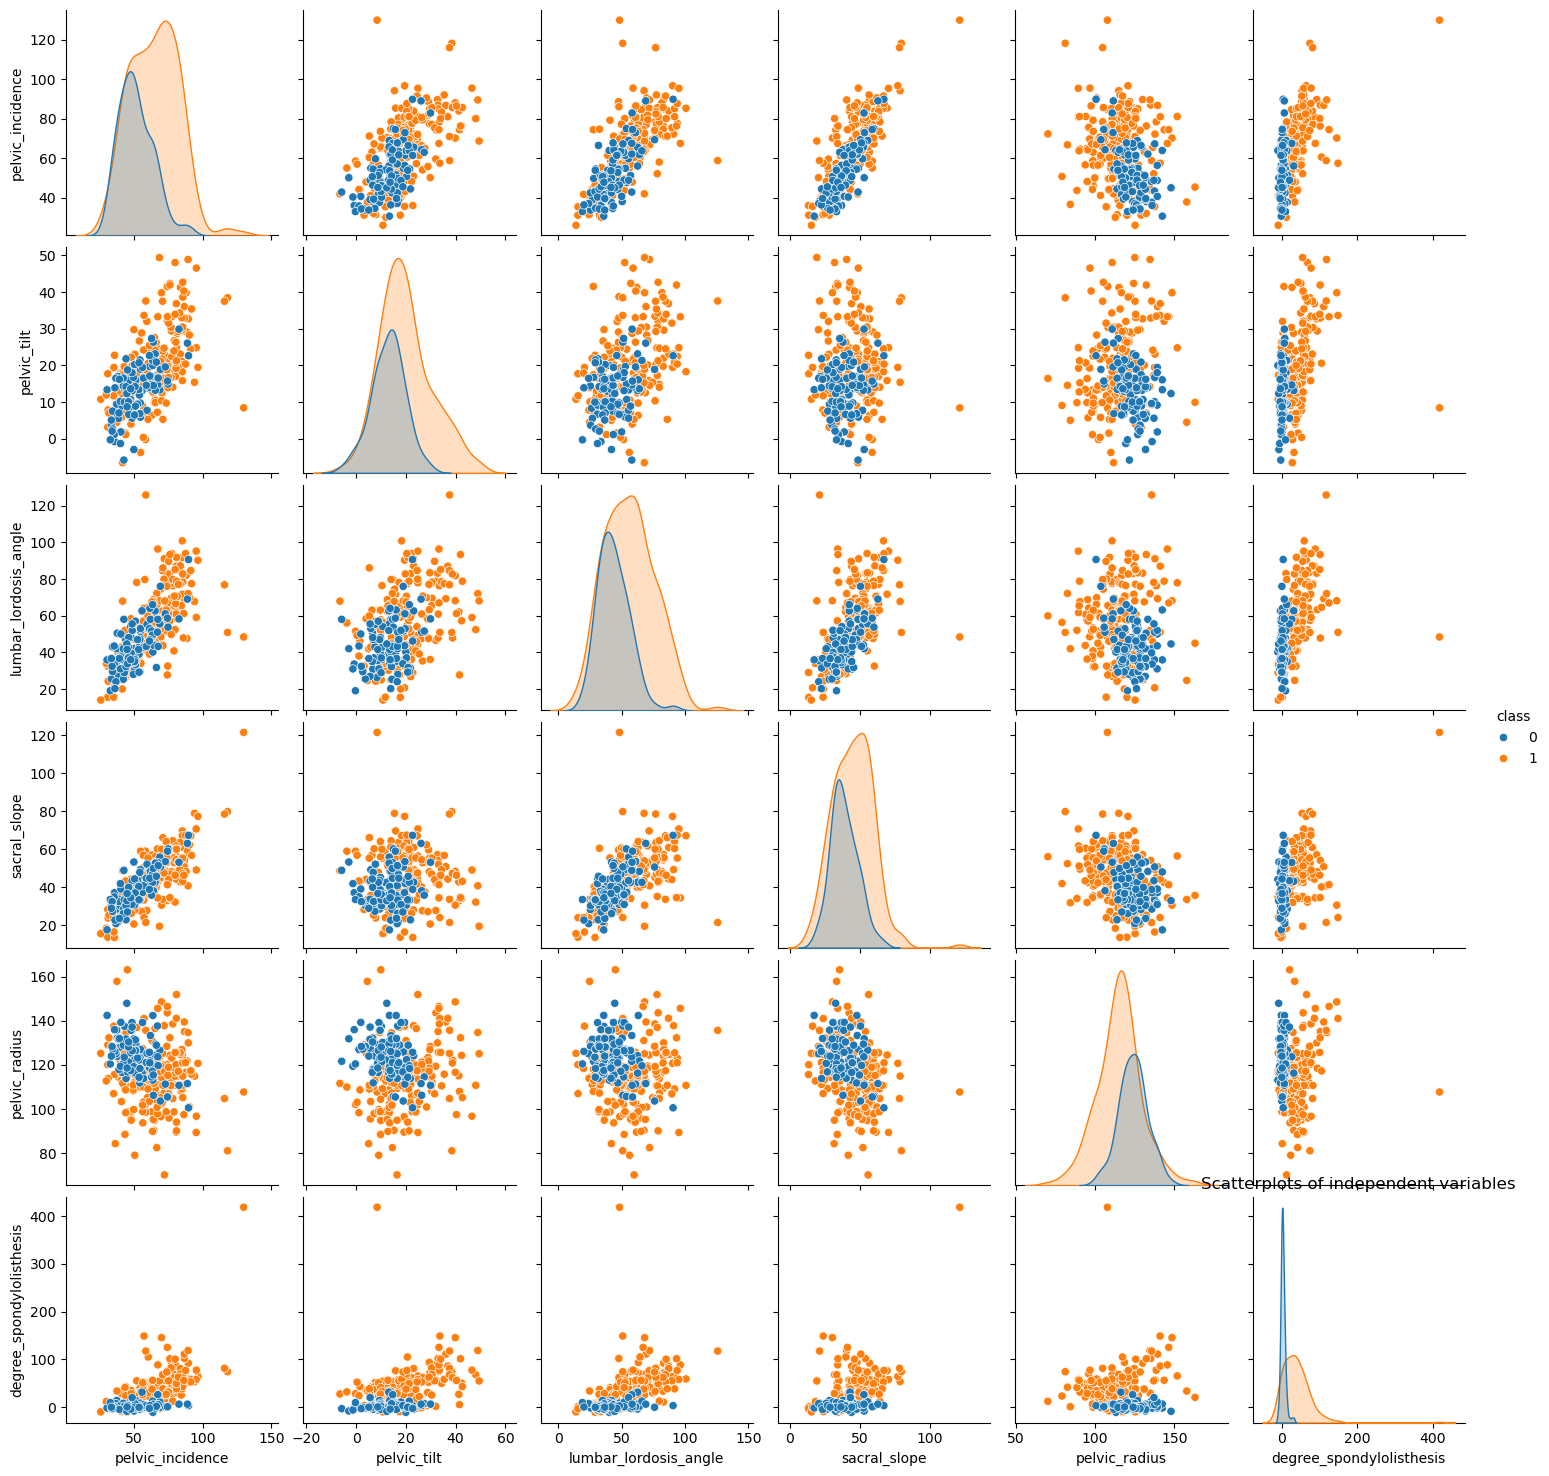

In [32]:
sns.pairplot(df, hue="class")
plt.title("Scatterplots of independent variables")
plt.show()

1) (b) ii. Make boxplots for each of the independent variables. Use color to show
Classes 0 and 1

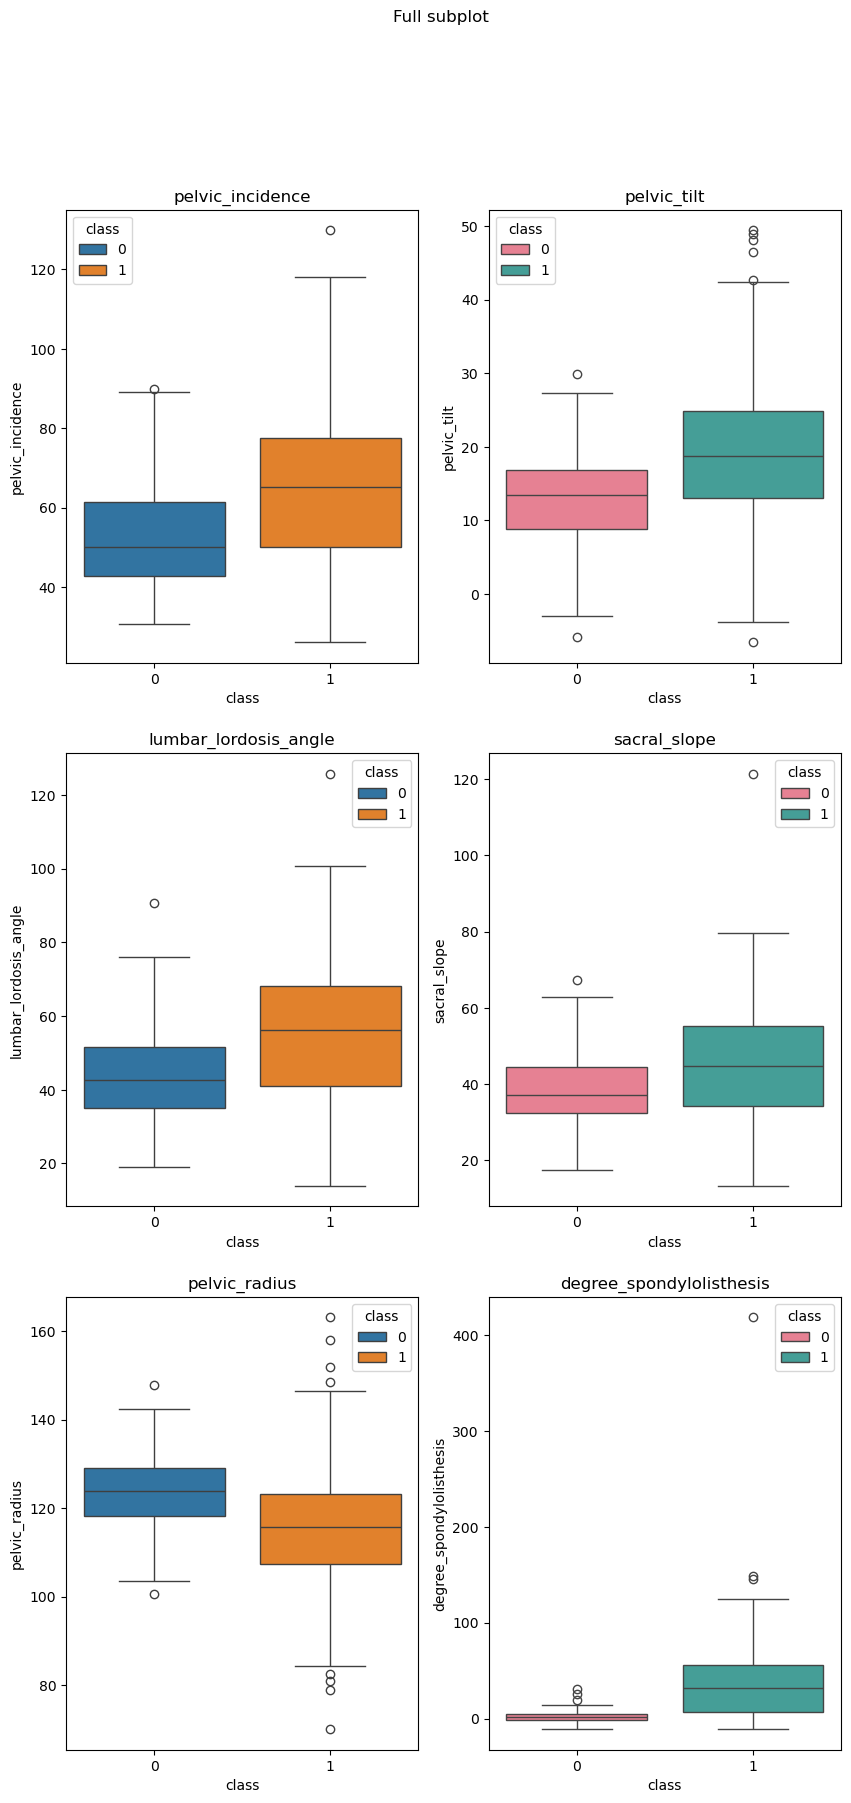

In [33]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 20))
fig.suptitle("Full subplot", fontsize=12)
sns.boxplot(x="class", y="pelvic_incidence", hue="class", data=df, ax=axes[0,0])
axes[0,0].set_title("pelvic_incidence")
sns.boxplot(x="class", y="pelvic_tilt", hue="class", data=df, palette="husl", ax=axes[0,1])
axes[0,1].set_title("pelvic_tilt")
sns.boxplot(x="class", y="lumbar_lordosis_angle", hue="class", data=df, ax=axes[1,0])
axes[1,0].set_title("lumbar_lordosis_angle")
sns.boxplot(x="class", y="sacral_slope", hue="class", data=df, palette="husl", ax=axes[1,1])
axes[1,1].set_title("sacral_slope")
sns.boxplot(x="class", y="pelvic_radius", hue="class", data=df, ax=axes[2,0])
axes[2,0].set_title("pelvic_radius")
sns.boxplot(x="class", y="degree_spondylolisthesis", hue="class", data=df, palette="husl", ax=axes[2,1])
axes[2,1].set_title("degree_spondylolisthesis")

plt.show()


1) b) iii. Select the first 70 rows of Class 0 and the first 140 rows of Class 1 as the
training set and the rest of the data as the test set

In [34]:
data1 = df[df["class"]==0]
data2 = df[df["class"]==1]
df1 = data1.head(70)
dnf1 = data1.iloc[70:]
df2 = data2.head(140)
dnf2 = data2.iloc[140:]
train_set = pd.concat([df1, df2], ignore_index=True)
test_set = pd.concat([dnf1, dnf2], ignore_index=True)
x_train_set = train_set.drop("class", axis=1)
y_train_set = train_set["class"]
x_test_set = test_set.drop("class", axis=1)
y_test_set = test_set["class"]
print(df1.shape, dnf1.shape, df2.shape, dnf2.shape, train_set.shape, test_set.shape)

(70, 7) (30, 7) (140, 7) (70, 7) (210, 7) (100, 7)


In [35]:
x_train_set.head()


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910


1) c) i. Code and package for KNN with Euclidean distance/metric

In [36]:
import math
def euclidean_distance(p1, p2):
    d = 0
    for i in range(len(p1)):
        d += (p2.iloc[i] - p1.iloc[i])**2
    return math.sqrt(d)

# print(euclidean_distance((0,0,0), (6,8, 10)))

In [37]:
from collections import Counter
def KNN(train_data, test_point, dist_funcn, k):
    distances = []
    for i in range(len(train_data)):
        d = dist_funcn(test_point, train_data.iloc[i][:-1])
        distances.append((d, train_data.iloc[i]))
    distances.sort(key=lambda x: x[0])
    neighbors = distances[:k]
    
    labels = [row[1].iloc[-1] for row in neighbors]
    return Counter(labels).most_common(1)[0][0]

print(KNN(train_set, x_test_set.iloc[0], euclidean_distance, 5))

1.0


In [38]:
knn1 = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn1.fit(x_train_set, y_train_set)
score = knn1.score(x_test_set, y_test_set)
print("KNN Score with Euclidean dist: ", score)


KNN Score with Euclidean dist:  0.92


1) c) ii. Test all test data with k nearest neighbours. Plot train and test errors wrt k. Find k*. Calculate confusion matrix, tpr, tnr, precision, f1-score. 

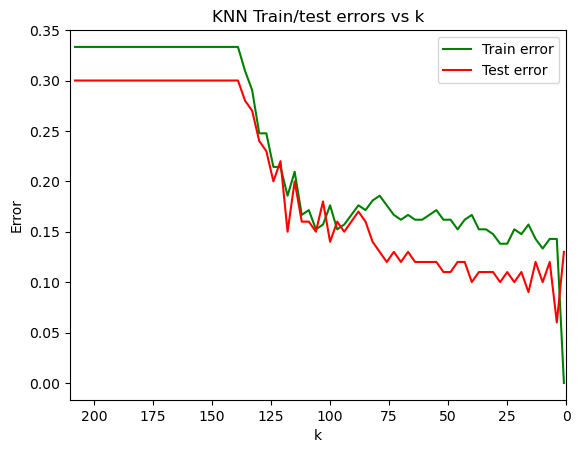

In [39]:
l_train_errors = []
l_test_errors = []
k_test_dict = {}
for k in range (208, 0, -3):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(x_train_set, y_train_set)
    y_pred = knn.predict(x_test_set)
    train_accuracy = knn.score(x_train_set, y_train_set)
    test_accuracy = knn.score(x_test_set, y_test_set)
    l_train_errors.append(1-train_accuracy)
    l_test_errors.append(1-test_accuracy)
    k_test_dict[1-test_accuracy] = k

plt.title("KNN Train/test errors vs k")
plt.xlabel("k")
plt.ylabel("Error")
plt.plot(list(range(208, 0, -3)), l_train_errors, 'g-', label='Train error')
plt.plot(list(range(208, 0, -3)), l_test_errors, 'r-', label='Test error')
plt.xlim(210,0)
plt.legend()
plt.show()


In [40]:
print("k* most suitable is one with least test error:", k_test_dict[min(l_test_errors)])
print("Minimum test error:", min(l_test_errors))
k_euclidean = k_test_dict[min(l_test_errors)]
euclidean_test_error = min(l_test_errors)

k* most suitable is one with least test error: 4
Minimum test error: 0.06000000000000005


In [41]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
knn = KNeighborsClassifier(n_neighbors=4, metric='euclidean')
knn.fit(x_train_set, y_train_set)
y_pred = knn.predict(x_test_set)
print("Confusion matrix:\n", confusion_matrix(y_test_set, y_pred))
print()
print("Classification report:\n", classification_report(y_test_set, y_pred))

Confusion matrix:
 [[25  5]
 [ 1 69]]

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89        30
           1       0.93      0.99      0.96        70

    accuracy                           0.94       100
   macro avg       0.95      0.91      0.93       100
weighted avg       0.94      0.94      0.94       100



In [42]:
true_pos = confusion_matrix(y_test_set, y_pred)[1][1]
true_neg = confusion_matrix(y_test_set, y_pred)[0][0]
false_pos = confusion_matrix(y_test_set, y_pred)[0][1]
false_neg = confusion_matrix(y_test_set, y_pred)[1][0]
tpos_rate = true_pos/(true_pos + false_neg)
tneg_rate = true_neg/(true_neg + false_pos)
print("True positive rate: ", tpos_rate)
print("True negative rate: ", tneg_rate)
print("Accuracy:", accuracy_score(y_test_set, y_pred))
print("F1 Score:", f1_score(y_test_set, y_pred))
print("Precision Score:", precision_score(y_test_set, y_pred))

True positive rate:  0.9857142857142858
True negative rate:  0.8333333333333334
Accuracy: 0.94
F1 Score: 0.9583333333333334
Precision Score: 0.9324324324324325


1) c) iii. Learning curve

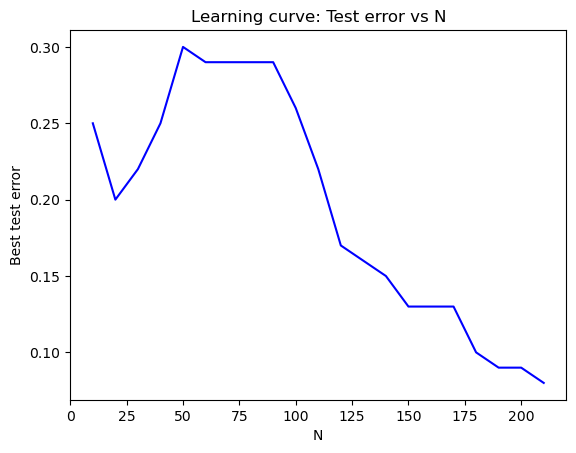

In [43]:
def optimal_k(metric, x_train_set, y_train_set, x_test_set, y_test_set, k_values):
    l_train_errors = []
    l_test_errors = []
    k_test_dict = {}
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(x_train_set, y_train_set)
        y_pred = knn.predict(x_test_set)
        train_accuracy = knn.score(x_train_set, y_train_set)
        test_accuracy = knn.score(x_test_set, y_test_set)
        l_train_errors.append(1-train_accuracy)
        l_test_errors.append(1-test_accuracy)
        k_test_dict[1-test_accuracy] = k
    return k_test_dict[min(l_test_errors)], l_test_errors[l_test_errors.index(min(l_test_errors))]


N_values = list(range(10, 211, 10))
test_error_list = []
for N in N_values:
    df1 = train_set[train_set["class"]==0].head(math.floor(N/3))
    dnf1 = train_set[train_set["class"]==1].head(N-math.floor(N/3))
    train_subset = pd.concat([df1, dnf1], ignore_index=True)
    x_train_set = train_subset.drop("class", axis=1)
    y_train_set = train_subset["class"]
    k_values = [i for i in range(1, N, 5)]
    k_opt, test_error = optimal_k('euclidean', x_train_set, y_train_set, x_test_set, y_test_set, k_values)
    test_error_list.append(test_error)
plt.title("Learning curve: Test error vs N")
plt.xlabel("N")
plt.ylabel("Best test error")
plt.plot(N_values, test_error_list, 'b-')

1) d) i.and ii. Variants of KNN - Minkowski distance, Manhattan, Chebyshev and Mahalanobis

In [44]:
from sklearn.metrics import DistanceMetric
def knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric="euclidean", p=2, weights='uniform'):
    d_k_test_dict = {}
    metric_test_error_list = []
    best_k_value = 0
    opt_k = []
    min_t_s = float('inf')
    if metric == 'mahalanobis':
        x_train_cov = np.cov(x_train_set.T)
        VI = np.linalg.pinv(x_train_cov)
        metric_param = DistanceMetric.get_metric('mahalanobis', VI=VI)
    for k in k_values:
        if metric == 'mahalanobis':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric_param, weights=weights)
        elif metric == 'minkowski':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p, weights=weights)
        elif metric == 'chebyshev':
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, p=float('inf'), weights=weights)
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights)
        knn.fit(x_train_set, y_train_set)
        score = knn.score(x_test_set, y_test_set)
        metric_test_error_list.append(1-score)
        d_k_test_dict[k] = 1-score
        if (1-score) < min_t_s and k != 1:
            min_t_s = 1-score
            best_k_value = k
    opt_k = [k for k, error in d_k_test_dict.items() if error == min_t_s]
    all_metric_test_errors[metric] = min_t_s
    all_metric_best_k[metric] = best_k_value
    return best_k_value, min_t_s, all_metric_test_errors, all_metric_best_k, opt_k

In [45]:
all_metric_test_errors = {}
all_metric_best_k = {}
opt_k=[]
k_values = [i for i in range(1, 197, 5)]

print("Euclidean:")
print("Best k*:", k_euclidean)
print("Minimum test error:", euclidean_test_error)
all_metric_test_errors["euclidean"] = euclidean_test_error
all_metric_best_k["euclidean"] = k_euclidean

best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='manhattan')
print("\nManhattan:")
print("Best k*:", best_k)
print("Minimum test error:", min_test_error)

log_p_values = [i/10 for i in range(0, 11, 1)]
manhattan_best_k = all_metric_best_k['manhattan']
d_k_test_dict = {}
print("\nMinkowski:")
minkowski_test_error_list= []
for i in log_p_values:
    knn1 = KNeighborsClassifier(n_neighbors=manhattan_best_k, metric='minkowski', p=10**i)
    knn1.fit(x_train_set, y_train_set)
    score = knn1.score(x_test_set, y_test_set)
    minkowski_test_error_list.append(1-score)
    d_k_test_dict[10**i] = 1-score
min_test_error = min(minkowski_test_error_list)
p_list = [p for p, error in d_k_test_dict.items() if error == min_test_error]
print("p* most suitable:", p_list[0])
print("Minimum test error:", min_test_error)
print("Best log10(p):", math.log10(p_list[0]))
all_metric_test_errors["minkowski"] = min_test_error
all_metric_best_k["minkowski"] = manhattan_best_k

best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='chebyshev')
print("\nChebyshev:")
print("Best k*:", best_k)
print("Minimum test error:", min_test_error)

best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='mahalanobis')
print("\nMahalanobis:")
print("Best k*:", best_k)
print("Minimum test error:", min_test_error)

print("all_metric_test_errors:", all_metric_test_errors)
print("all_metric_best_k:", all_metric_best_k)

Euclidean:
Best k*: 4
Minimum test error: 0.06000000000000005

Manhattan:
Best k*: 6
Minimum test error: 0.10999999999999999

Minkowski:
p* most suitable: 3.9810717055349722
Minimum test error: 0.06000000000000005
Best log10(p): 0.6

Chebyshev:
Best k*: 16
Minimum test error: 0.07999999999999996

Mahalanobis:
Best k*: 6
Minimum test error: 0.16000000000000003
all_metric_test_errors: {'euclidean': 0.06000000000000005, 'manhattan': 0.10999999999999999, 'minkowski': 0.06000000000000005, 'chebyshev': 0.07999999999999996, 'mahalanobis': 0.16000000000000003}
all_metric_best_k: {'euclidean': 4, 'manhattan': 6, 'minkowski': 6, 'chebyshev': 16, 'mahalanobis': 6}


In [46]:
table1 = pd.DataFrame(all_metric_test_errors.items(), columns= ['Metric', 'Test Error'])
table2 = pd.DataFrame(all_metric_best_k.items(), columns= ['Metric', 'Best k*'])
table = pd.concat([table1, table2["Best k*"]], axis=1)
display(table)

,Metric,Test Error,Best k*
0,euclidean,0.06,4
1,manhattan,0.11,6
2,minkowski,0.06,6
3,chebyshev,0.08,16
4,mahalanobis,0.16,6


1) e) Weighted voting

In [47]:
all_metric_test_errors = {}
all_metric_best_k = {}
k_values = [i for i in range(1, 197, 5)]

best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='euclidean', weights='distance')
print("Euclidean:")
print("Best k*:", best_k)
print("optimal_k:", opt_k)
print("Minimum test error:", min_test_error)
all_metric_test_errors["euclidean"] = min_test_error
all_metric_best_k["euclidean"] = best_k

best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='manhattan', weights='distance')
print("\nManhattan:")
print("Best k*:", best_k)
print("optimal_k:", opt_k)
print("Minimum test error:", min_test_error)


best_k, min_test_error, all_metric_test_errors, all_metric_best_k, opt_k = knn_best_k_test_error(x_train_set, y_train_set, x_test_set, y_test_set, k_values, all_metric_test_errors, all_metric_best_k, metric='chebyshev', weights='distance')
print("\nChebyshev:")
print("Best k*:", best_k)
print("optimal_k:", opt_k)
print("Minimum test error:", min_test_error)
all_metric_best_k["chebyshev"] = opt_k

print("all_metric_test_errors:", all_metric_test_errors)
print("all_metric_best_k:", all_metric_best_k)

Euclidean:
Best k*: 6
optimal_k: [6]
Minimum test error: 0.09999999999999998

Manhattan:
Best k*: 26
optimal_k: [26]
Minimum test error: 0.09999999999999998

Chebyshev:
Best k*: 16
optimal_k: [16, 31, 36, 41, 61]
Minimum test error: 0.10999999999999999
all_metric_test_errors: {'euclidean': 0.09999999999999998, 'manhattan': 0.09999999999999998, 'chebyshev': 0.10999999999999999}
all_metric_best_k: {'euclidean': 6, 'manhattan': 26, 'chebyshev': [16, 31, 36, 41, 61]}


In [48]:
table1 = pd.DataFrame(all_metric_test_errors.items(), columns= ['Metric', 'Test Error'])
table2 = pd.DataFrame(all_metric_best_k.items(), columns= ['Metric', 'Best k*'])
table = pd.concat([table1, table2["Best k*"]], axis=1)
display(table)

,Metric,Test Error,Best k*
0,euclidean,0.10,6
1,manhattan,0.10,26
2,chebyshev,0.11,"[16, 31, 36, 41, 61]"


1) f) Lowest training error - was 0, when k = 1, since every data point's nearest neighbour is itself, i.e. distance = 0. The class prediction will always be perfect and thus the error rate is 0%.

References:


https://stackoverflow.com/questions/66283445/how-do-i-train-and-test-data-using-k-nearest-neighbour


https://medium.com/@nikhilsborade0412/choosing-the-right-k-for-knn-a-deep-dive-into-model-performance-86d8371fef78


https://www.geeksforgeeks.org/maths/minskowski-distance/


https://scikit-learn.org/0.16/modules/generated/sklearn.neighbors.DistanceMetric.html


https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/


https://stackoverflow.com/questions/34643548/how-to-use-mahalanobis-distance-in-sklearn-distancemetrics


https://www.kaggle.com/code/kane6543/knn-with-euclidean-minkowski-manhattan-distance



AI Prompts:


How to implement covariance matrix in Mahalanobis distance

Fix minor errors in code

One single function

In [49]:
# INDIVIDUAL DRAFTS

In [50]:
# all_metric_test_errors = {}
# all_metric_best_k = {}

In [51]:
# k_values = [i for i in range(1, 197, 5)]
# d_k_test_dict = {}
# manhattan_test_error_list = []
# min_t_s = float('inf')
# best_k = 0
# for k in k_values:
#     knn1 = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
#     knn1.fit(x_train_set, y_train_set)
#     score = knn1.score(x_test_set, y_test_set)
#     manhattan_test_error_list.append(1-score)
#     d_k_test_dict[k] = 1-score
#     if (1-score) < min_t_s and k!=1:
#         min_t_s = 1-score
#         best_k = k


# min_test_error = min(manhattan_test_error_list)
# k_list = [k for k, error in d_k_test_dict.items() if error == min_test_error]
# print("k* most suitable:", k_list)
# print("Best k*:", best_k)
# print("Minimum test error:", min_test_error)
# all_metric_test_errors["manhattan"] = min_test_error
# all_metric_best_k["manhattan"] = best_k
# all_metric_test_errors


In [52]:
# log_p_values = [i/10 for i in range(0, 11, 1)]
# d_k_test_dict = {}
# minkowski_test_error_list = []
# for i in log_p_values:
#     knn1 = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=10**i)
#     knn1.fit(x_train_set, y_train_set)
#     score = knn1.score(x_test_set, y_test_set)
#     minkowski_test_error_list.append(1-score)
#     d_k_test_dict[10**i] = 1-score
# min_test_error = min(minkowski_test_error_list)
# p_list = [p for p, error in d_k_test_dict.items() if error == min_test_error]
# print("p* most suitable:", p_list[0])
# print("Minimum test error:", min_test_error)
# print("Best log10(p):", math.log10(p_list[0]))
# all_metric_test_errors["minkowski"] = min_test_error
# all_metric_best_k["minkowski"] = best_k

# print("all_metric_test_errors:", all_metric_test_errors)
# print("all_metric_best_k:", all_metric_best_k)

In [53]:
# k_values = [i for i in range(1, 197, 5)]
# d_k_test_dict = {}
# chebyshev_test_error_list = []
# min_t_s = float('inf')
# best_k = 0
# for k in k_values:
#     knn1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=float('inf'))
#     knn1.fit(x_train_set, y_train_set)
#     score = knn1.score(x_test_set, y_test_set)
#     chebyshev_test_error_list.append(1-score)
#     d_k_test_dict[k] = 1-score
#     if (1-score) < min_t_s and k!=1:
#         min_t_s = 1-score
#         best_k = k


# min_test_error = min(chebyshev_test_error_list)
# k_list = [k for k, error in d_k_test_dict.items() if error == min_test_error]
# print("k* most suitable:", k_list)
# print("Best k*:", best_k)
# print("Minimum test error:", min_test_error)
# all_metric_test_errors["chebyshev"] = min_test_error
# all_metric_best_k["chebyshev"] = best_k

# print("all_metric_test_errors:", all_metric_test_errors)
# print("all_metric_best_k:", all_metric_best_k)

In [54]:
# from sklearn.metrics import DistanceMetric
# x_train_cov = np.cov(x_train_set.T)
# VI = np.linalg.pinv(x_train_cov) 
# mahalanobis = DistanceMetric.get_metric('mahalanobis', VI=VI)


In [55]:
# k_values = [i for i in range(1, 197, 5)]
# d_k_test_dict = {}
# # x_train_cov = np.cov(x_train_set.T, rowvar=False)
# # VI = np.linalg.inv(x_train_cov)
# mahalanobis_test_error_list = []

# min_t_s = float('inf')
# best_k_mahalanobis = 0
# for k in k_values:
#     knn1 = KNeighborsClassifier(n_neighbors=k, metric=mahalanobis)
#     knn1.fit(x_train_set, y_train_set)
#     score = knn1.score(x_test_set, y_test_set)
#     mahalanobis_test_error_list.append(1-score)
#     d_k_test_dict[k] = 1-score
#     if (1-score) < min_t_s and k!=1:
#         min_t_s = 1-score
#         best_k_mahalanobis = k


# min_test_error = min(mahalanobis_test_error_list)
# k_list = [k for k, error in d_k_test_dict.items() if error == min_test_error]
# print("k* most suitable:", k_list)
# print("Best k*:", best_k_mahalanobis)
# print("Minimum test error:", min_test_error)
# all_metric_test_errors["mahalanobis"] = min_test_error
# all_metric_best_k["mahalanobis"] = best_k_mahalanobis
# print("all_metric_test_errors:", all_metric_test_errors)
# print("all_metric_best_k:", all_metric_best_k)